# Assignment 3

# Reza Rezaitehrani

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Clustering and Resampling

Let's set up our workspace and use the **Iris dataset** from `scikit-learn`. This dataset is a classic dataset in machine learning and statistics, widely used for clustering tasks. It consists of many samples of iris flowers. Here are the key features and characteristics of the dataset:

##### Features:
1. **Sepal Length**: The length of the sepal in centimeters.
2. **Sepal Width**: The width of the sepal in centimeters.
3. **Petal Length**: The length of the petal in centimeters.
4. **Petal Width**: The width of the petal in centimeters.

In [1]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


#### **Question 1:** 
#### Data inspection

#### Load the Iris dataset:

Use scikit-learn to load the Iris dataset and convert it into a Pandas DataFrame.
Display the first few rows of the dataset. How many observations (rows) and features (columns) does the dataset contain?
150 rows, 4 columns

In [4]:

# Reza Rezaitehrani

from sklearn.datasets import load_iris
# Load the Iris dataset
iris_data = load_iris()

# Convert to DataFrame
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)

# Display the DataFrame
print(iris_df)

# Your code here...
print(iris_df.shape) # Print the number of rows and columns

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
(150, 4)


#### **Question 2:** 
#### Data-visualization

Let's create plots to visualize the relationships between the features (sepal length, sepal width, petal length, petal width).


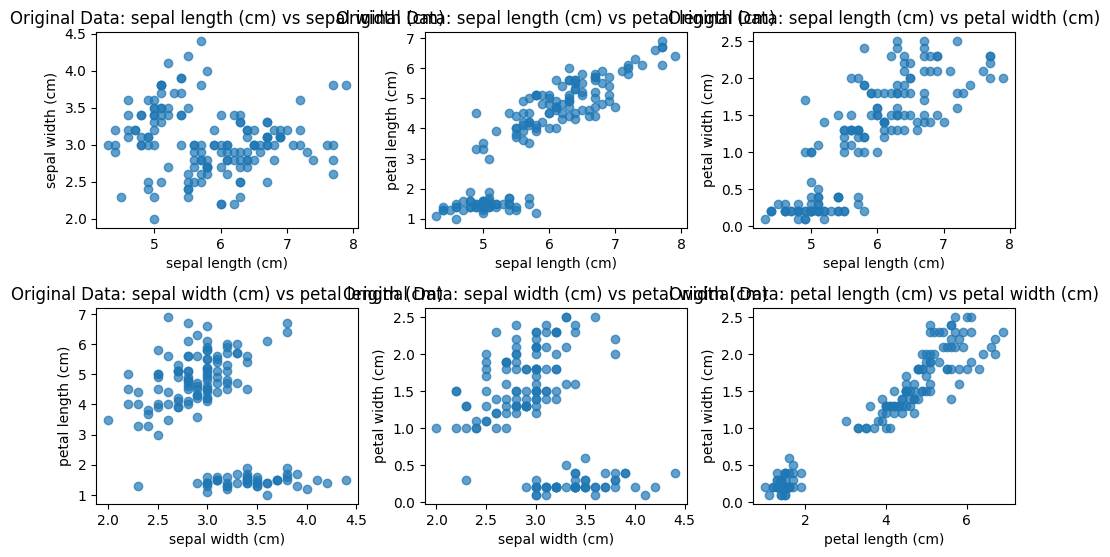

In [15]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(10, 8))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = iris_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(iris_df, feature_names, title_prefix='Original Data: ')

**Question:**
- Do you notice any patterns or relationships between the different features? How might these patterns help in distinguishing between different species?

> Your answer...

#Petal Length-Petal Width have strong positive correlation; distinct clusters, good species separation.
Sepal Length-Sepal Width: Have weaker correlation; less clear species separation.
Petal-Sepal Combinations: Have good species separation, especially involving petal measurements.
Species Distinction: Petal measurements are more effective than sepal measurements. Clear clusters aid species identification, but I think some overlap exists.

#### **Question 3:** 
#### Data cleaning

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all the features in the dataset
scaled_features = scaler.fit_transform(iris_df)

# Create a new DataFrame with scaled features
scaled_iris_df = pd.DataFrame(scaled_features, columns=iris_data.feature_names)

# Display the first few rows of the scaled DataFrame
print(scaled_iris_df.head())

Why is it important to standardize the features of a dataset before applying clustering algorithms like K-Means? Discuss the implications of using unstandardized data in your analysis.

> Your answer here ...
Standardizing features ensures that all features contribute equally to the distance calculations in K-Means, leading to more accurate, unbiased, and interpretable clustering results.
I think prevents features with larger scales from dominating the clustering process. 

#### **Question 4:** 
#### K-means clustering 

Apply the K-Means clustering algorithm to the Iris dataset. Choose the value 3 for the number of clusters (`k=3`) and fit the model. Assign cluster labels to the original data and add them as a new column in the DataFrame.

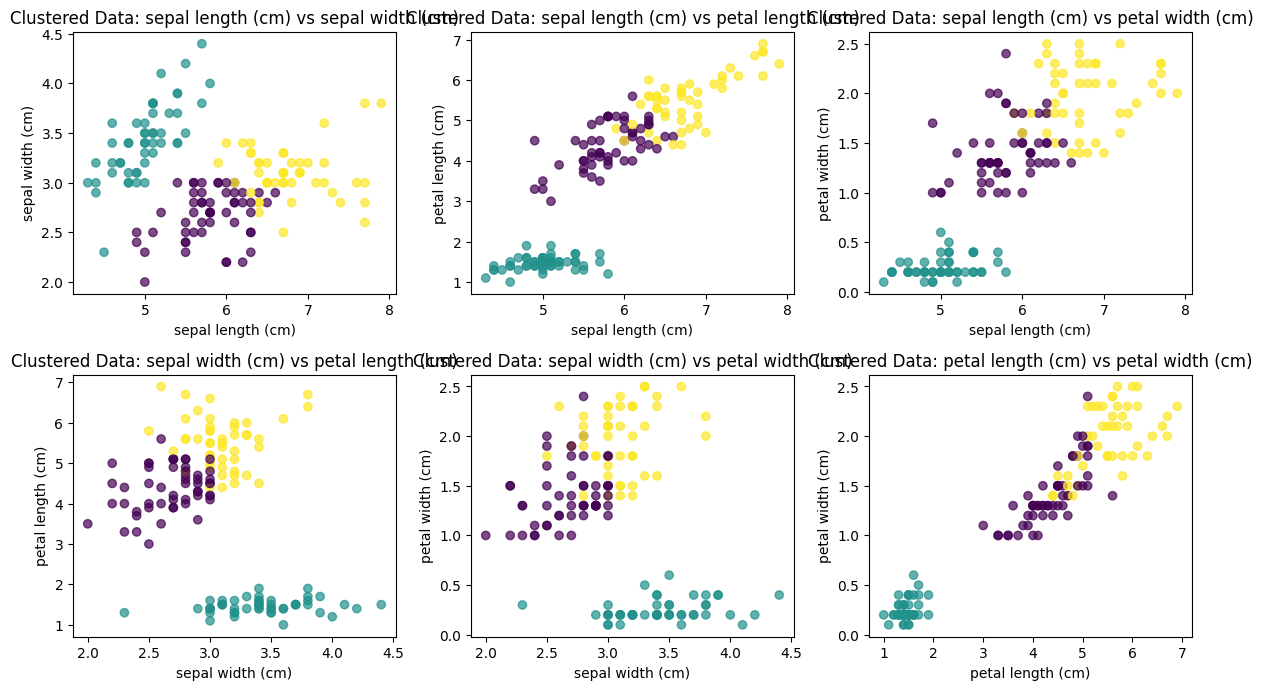

In [23]:
# Your answer...

#iris_df = 🤷‍♂️

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
feature_names = iris_df.columns

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(iris_df)
scaled_iris_df = pd.DataFrame(scaled_features, columns=iris.feature_names)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(scaled_iris_df)
iris_df['cluster'] = kmeans.labels_

def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """Helper function to create scatter plots for all possible pairs of features."""
    plt.figure(figsize=(12, 10))
    plot_number = 1
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names) - 1, len(feature_names) - 1, plot_number)
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]],
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            plot_number += 1
    plt.tight_layout()
    plt.show()

# Plot the clustered data
plot_feature_pairs(iris_df, feature_names, color_labels=iris_df['cluster'], title_prefix='Clustered Data: ')



# Use the helper function to plot scatter plots, colored by cluster labels
#plot_feature_pairs(iris_df, feature_names, color_labels=iris_df['Cluster'], title_prefix='Clustered Data: ')

We chose `k=3` for the number of clusters arbitrarily. However, in a real-world scenario, it is important to determine the optimal number of clusters using appropriate methods.

**Question**: What is one method commonly used to determine the optimal number of clusters in K-means clustering, and why is this method helpful?

> Your answer here...

The "elbow method" helps to find the optimal number of clusters by identifying the point where adding more clusters provides little improvement in reducing the within-cluster variance.

 It's a simple, visual, and effective way to guide the selection of k in K-Means.

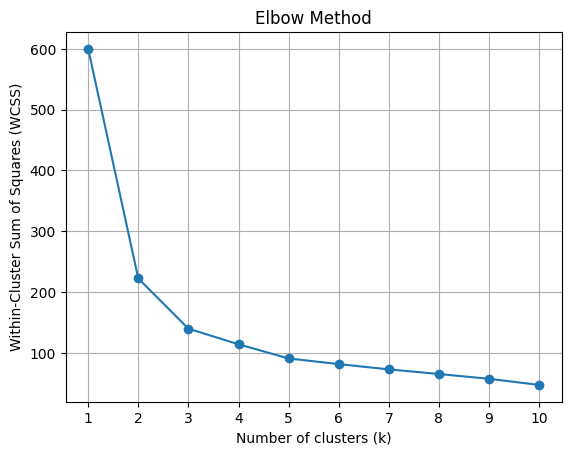

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(iris_df)
scaled_iris_df = pd.DataFrame(scaled_features, columns=iris.feature_names)

# Calculate WCSS for a range of k values
wcss = []
for k in range(1, 11):  # Test k from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(scaled_iris_df)
    wcss.append(kmeans.inertia_)  # Inertia_ gives the WCSS

# Plot the WCSS values
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method')
plt.xticks(range(1, 11))  # Ensure x-axis ticks are integers
plt.grid(True)
plt.show()

#### **Question 5:** 
#### Bootstrapping 

Implement bootstrapping on the mean of Petal Width. Generate 10000 bootstrap samples, calculate the mean for each sample, and compute a 90% confidence interval.

In [25]:
# Your answer here...

#mean_petal_width = 🤷‍♂️
#np.random.seed(123)
#lower_bound = 🤷‍♂️
#upper_bound = 🤷‍♂️
# Display the result
#print(f"Mean of Petal Width: {mean_petal_width}")
#print(f"90% Confidence Interval of Mean Petal Width: ({lower_bound}, {upper_bound})

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Extract Petal Width
petal_width = iris_df['petal width (cm)']

# Number of bootstrap samples
n_bootstrap = 10000

# Create empty array to store bootstrap means
bootstrap_means = np.empty(n_bootstrap)

# Perform bootstrapping
for i in range(n_bootstrap):
    # Resample with replacement
    bootstrap_sample = np.random.choice(petal_width, size=len(petal_width), replace=True)
    # Calculate the mean of the bootstrap sample
    bootstrap_means[i] = np.mean(bootstrap_sample)

# Calculate the 90% confidence interval
alpha = 0.1  # For a 90% CI, alpha is 1 - 0.9 = 0.1
lower_bound = np.quantile(bootstrap_means, alpha / 2)
upper_bound = np.quantile(bootstrap_means, 1 - alpha / 2)

print(f"90% Confidence Interval for Petal Width Mean: [{lower_bound:.4f}, {upper_bound:.4f}]")

90% Confidence Interval for Petal Width Mean: [1.0980, 1.3013]


**Question:**
- Why do we use bootstrapping in this context? What does it help us understand about the mean?


>  Your answer...

Bootstrapping allows us to estimate the uncertainty associated with our sample mean by simulating repeated sampling from the population.

 The resulting confidence interval provides a range of plausible values for the true population mean, giving us a better understanding of the reliability of our estimate.
 Bootstrapping is a non-parametric method, meaning it doesn't assume any specific distribution for the underlying population (like normality).This is a significant advantage when we don't know the true population distribution. 

 

**Question:**
- What is the purpose of calculating the confidence interval from the bootstrap samples? How does it help us interpret the variability of the estimate?

> Your answer...

The confidence interval gives us a "margin of error" for our sample mean. It tells us how much our sample mean might bounce around if we were to take different samples.

 A wider margin of error means our estimate is less precise, while a narrower margin of error means our estimate is more precise.   


Sources and related content

"Bootstrap Estimates of Confidence Intervals"

https://library.virginia.edu/data/articles/bootstrap-estimates-of-confidence-intervals#:~:text=These%20resamples%20can%20be%20used,median%2C%20standard%20deviation%2C%20etc


**Question:**

- Reflect on the variability observed in the bootstrapped means and discuss whether the mean of the Petal Width appears to be a stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means.

> Your answer here...

By examining the spread of the bootstrapped means and the width of the confidence interval in relation to the original data, we can assess the stability and reliability of the mean estimate. A narrow confidence interval and a tight distribution of bootstrapped means indicate a more stable and reliable estimate.

# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is thoroughly inspected for the number of variables, observations, and data types, and relevant insights are noted. | Data inspection is missing or lacks detail.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots) are well-constructed and correctly interpreted to explore relationships between features and species. | Visualizations are poorly constructed or not correctly interpreted. |
| **Clustering Implementation**                           | K-Means clustering is correctly implemented, and cluster labels are appropriately assigned to the dataset.            | K-Means clustering is missing or incorrectly implemented. |
| **Bootstrapping Process**                              | Bootstrapping is correctly performed, and results are used to assess variable mean stability. | Bootstrapping is missing or incorrectly performed. |

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 01/26/2025`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-4-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
